# 31 — Conservation Gap Analysis

Compare GNN-SDM predicted conservation priorities against existing
Swiss protected areas (WDPA). Are the right areas protected?

**Pipeline**:
1. Compute circuit-theory connectivity for 6 threatened species
2. Aggregate into a multi-species priority surface (mean suitability + current flow)
3. Overlay with WDPA protected areas
4. Quantify: what fraction of high-priority patches are protected? What gaps exist?

### Setup

In [1]:
import config
import numpy as np
import pandas as pd
import pickle
import time
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from data_utils import load_species_patches, load_patch_data

with open('landscape_graph.pkl', 'rb') as f:
    G = pickle.load(f)

patch_features, patch_counts, feature_names = load_patch_data()
n_patches = G.number_of_nodes()
print(f'Graph: {n_patches:,} nodes, {G.number_of_edges():,} edges')

species_patches, species_counts = load_species_patches(config, min_records=100)

# Load GNN suitability
scores_npz = np.load('gnn_training_output/suitability_scores.npz')
def get_suitability(sp):
    key = sp.replace(' ', '_')
    return scores_npz[key] if key in scores_npz.files else None

print(f'Suitability scores for {len(scores_npz.files):,} species')

Patches: 166,464, features: 12
Graph: 166,464 nodes, 465,833 edges
GBIF records: 22,723,973
Species with >= 100 records: 3,756
Suitability scores for 3,751 species


### Circuit-theory computation for 6 threatened species

In [2]:
def compute_current_flow(G, suitability, core_patches, n_pairs=5, min_component_size=3):
    """Circuit-theory current flow between known population clusters."""
    n = G.number_of_nodes()
    nodes = sorted(G.nodes())
    node_to_idx = {nd: i for i, nd in enumerate(nodes)}

    # Build conductance Laplacian
    L = lil_matrix((n, n), dtype=np.float64)
    for u, v in G.edges():
        i, j = node_to_idx[u], node_to_idx[v]
        conductance = max(1e-4, (suitability[u] + suitability[v]) / 2)
        L[i, j] -= conductance
        L[j, i] -= conductance
        L[i, i] += conductance
        L[j, j] += conductance
    L = csr_matrix(L)

    # Core components from actual observations
    cores = set(core_patches)
    core_subgraph = G.subgraph(cores)
    components = [c for c in nx.connected_components(core_subgraph)
                  if len(c) >= min_component_size]
    components.sort(key=len, reverse=True)

    if len(components) < 2:
        return np.zeros(len(suitability))

    # Solve current flow between top component pairs
    current = np.zeros(n, dtype=np.float64)
    n_solve = min(len(components), n_pairs)

    for pair_i in range(n_solve - 1):
        src_comp = components[pair_i]
        gnd_comp = components[pair_i + 1]

        rhs = np.zeros(n)
        src_idx = [node_to_idx[nd] for nd in src_comp]
        gnd_idx = [node_to_idx[nd] for nd in gnd_comp]
        for idx in src_idx:
            rhs[idx] = 1.0 / len(src_idx)
        for idx in gnd_idx:
            rhs[idx] = -1.0 / len(gnd_idx)

        pin = gnd_idx[0]
        L_solve = L.copy().tolil()
        L_solve[pin, :] = 0
        L_solve[pin, pin] = 1
        rhs[pin] = 0

        voltages = spsolve(csr_matrix(L_solve), rhs)

        node_current = np.zeros(n)
        for u, v in G.edges():
            i, j = node_to_idx[u], node_to_idx[v]
            cond = max(1e-4, (suitability[u] + suitability[v]) / 2)
            ec = abs(cond * (voltages[i] - voltages[j]))
            node_current[i] += ec
            node_current[j] += ec
        current += node_current

    # Map back to patch IDs
    result = np.zeros(len(suitability))
    for nd, idx in node_to_idx.items():
        result[nd] = current[idx]
    return result

In [3]:
THREATENED = [
    'Cypripedium calceolus', 'Drosera rotundifolia', 'Pulsatilla vulgaris',
    'Gladiolus palustris', 'Aquilegia alpina', 'Stipa pennata',
]

all_suitability = np.zeros(n_patches, dtype=np.float64)
all_current = np.zeros(n_patches, dtype=np.float64)

t0 = time.time()
for i, sp in enumerate(THREATENED):
    suit = get_suitability(sp)
    presence = species_patches.get(sp, set())
    print(f'[{i+1}/{len(THREATENED)}] {sp} ({len(presence)} patches)...')

    current = compute_current_flow(G, suit, presence, n_pairs=6)

    # Normalise current to [0,1] per species before averaging
    if current.max() > 0:
        current_norm = current / current.max()
    else:
        current_norm = current

    all_suitability += suit
    all_current += current_norm

    elapsed = time.time() - t0
    print(f'  Done ({elapsed:.0f}s elapsed)')

# Average across species
mean_suitability = all_suitability / len(THREATENED)
mean_current = all_current / len(THREATENED)

# Combined priority score: suitability + connectivity
priority_score = (mean_suitability + mean_current) / 2

print(f'\nTotal time: {time.time()-t0:.0f}s')
print(f'Mean priority score: {priority_score.mean():.4f}')
print(f'Max priority score: {priority_score.max():.4f}')

[1/6] Cypripedium calceolus (2423 patches)...
  Done (34s elapsed)
[2/6] Drosera rotundifolia (1499 patches)...
  Done (64s elapsed)
[3/6] Pulsatilla vulgaris (550 patches)...
  Done (94s elapsed)
[4/6] Gladiolus palustris (329 patches)...
  Done (124s elapsed)
[5/6] Aquilegia alpina (679 patches)...
  Done (154s elapsed)
[6/6] Stipa pennata (392 patches)...
  Done (192s elapsed)

Total time: 192s
Mean priority score: 0.0586
Max priority score: 0.6659


### Overlay with protected areas

In [4]:
import geopandas as gpd
from rasterio.transform import rowcol
from s3_utils import load_zarr

# Load protected areas
pa = gpd.read_file('protected_areas_ch.geojson')
print(f'Protected areas: {len(pa)}')
print(f'Categories: {pa["iucn_cat"].value_counts().to_dict()}')

# Load patch labels raster to map PA polygons -> patch IDs
patch_labels_da = load_zarr(
    config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
    name='patch_label',
)
patch_labels = patch_labels_da.values
transform = patch_labels_da.rio.transform()

# Rasterise protected areas onto the patch grid
from rasterio.features import rasterize
from rasterio.transform import from_bounds

h, w = patch_labels.shape
bounds = patch_labels_da.rio.bounds()
raster_transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], w, h)

# Burn PA polygons into a binary mask
pa_shapes = [(geom, 1) for geom in pa.geometry if geom is not None]
pa_mask = rasterize(
    pa_shapes, out_shape=(h, w), transform=raster_transform,
    fill=0, dtype=np.uint8
)

# Map to patch level (vectorised with bincount)
valid = patch_labels >= 0
patch_ids_flat = patch_labels[valid].astype(np.int64)
pa_flat = pa_mask[valid].astype(np.float64)

protected_sum = np.bincount(patch_ids_flat, weights=pa_flat, minlength=n_patches)
total_count = np.bincount(patch_ids_flat, minlength=n_patches)

frac_protected = np.zeros(n_patches)
nonzero = total_count > 0
frac_protected[nonzero] = protected_sum[nonzero] / total_count[nonzero]

protected_patches = set(np.where(frac_protected > 0.0)[0])
print(f'\nProtected patches (any overlap): {len(protected_patches):,} / {n_patches:,} '
      f'({len(protected_patches)/n_patches*100:.1f}%)')

Protected areas: 10522
Categories: {'IV': 6629, 'Not Assigned': 3302, 'Ia': 553, 'Not Reported': 37, 'VI': 1}

Protected patches (any overlap): 18,948 / 166,464 (11.4%)


### Restrict to Switzerland

The patch raster covers a bounding box that extends into neighbouring countries.
Since our PA data is Swiss-only, patches outside Switzerland would incorrectly
appear as unprotected. We mask to Swiss territory using a Natural Earth boundary.

In [5]:
# Load Switzerland boundary and rasterise onto the same grid
ch_boundary = gpd.read_file('switzerland_boundary.geojson')
ch_shapes = [(geom, 1) for geom in ch_boundary.geometry if geom is not None]
ch_mask = rasterize(
    ch_shapes, out_shape=(h, w), transform=raster_transform,
    fill=0, dtype=np.uint8
)

# Map to patch level: fraction of each patch inside Switzerland
ch_flat = ch_mask[valid].astype(np.float64)
ch_sum = np.bincount(patch_ids_flat, weights=ch_flat, minlength=n_patches)
frac_in_ch = np.zeros(n_patches)
frac_in_ch[nonzero] = ch_sum[nonzero] / total_count[nonzero]

# Swiss patches = majority of pixels inside Switzerland
swiss_patches = set(np.where(frac_in_ch > 0.5)[0])
n_swiss = len(swiss_patches)
print(f'Swiss patches: {n_swiss:,} / {n_patches:,} ({n_swiss/n_patches*100:.1f}%)')
print(f'Patches outside Switzerland (excluded): {n_patches - n_swiss:,}')

# Restrict protected patches to Swiss territory only
protected_patches = protected_patches & swiss_patches
print(f'\nProtected Swiss patches (any PA overlap): {len(protected_patches):,} / {n_swiss:,} '
      f'({len(protected_patches)/n_swiss*100:.1f}%)')

Swiss patches: 65,298 / 166,464 (39.2%)
Patches outside Switzerland (excluded): 101,166

Protected Swiss patches (any PA overlap): 18,695 / 65,298 (28.6%)


### Analysis 1: Are we protecting the right places?

Compare mean habitat suitability inside vs outside protected areas.
If protection is well-targeted, suitability should be significantly
higher inside PAs than outside.

In [6]:
protected_arr = np.array(list(protected_patches))
unprotected_arr = np.array(list(swiss_patches - protected_patches))

print('=== Analysis 1: Protection Effectiveness (Switzerland only) ===')
print(f'Swiss patches: {n_swiss:,}')
print(f'Protected patches: {len(protected_arr):,} ({len(protected_arr)/n_swiss*100:.1f}%)')
print(f'Unprotected patches: {len(unprotected_arr):,}')

print(f'\n{"Species":30s} {"Suit (protected)":>17s} {"Suit (unprotected)":>19s} {"Ratio":>7s}')
print('-' * 78)

for sp in THREATENED:
    suit = get_suitability(sp)
    s_in = suit[protected_arr].mean()
    s_out = suit[unprotected_arr].mean()
    ratio = s_in / max(s_out, 1e-8)
    print(f'{sp:30s} {s_in:>17.4f} {s_out:>19.4f} {ratio:>7.2f}x')

# Aggregate
s_in_all = mean_suitability[protected_arr].mean()
s_out_all = mean_suitability[unprotected_arr].mean()
print(f'{"--- MEAN (all 6) ---":30s} {s_in_all:>17.4f} {s_out_all:>19.4f} {s_in_all/max(s_out_all,1e-8):>7.2f}x')

print(f'\nInterpretation: ratio > 1 means protected areas have higher suitability')
print(f'for threatened species than the unprotected landscape.')

=== Analysis 1: Protection Effectiveness (Switzerland only) ===
Swiss patches: 65,298
Protected patches: 18,695 (28.6%)
Unprotected patches: 46,603

Species                         Suit (protected)  Suit (unprotected)   Ratio
------------------------------------------------------------------------------
Cypripedium calceolus                     0.2199              0.1452    1.51x
Drosera rotundifolia                      0.1640              0.1016    1.61x
Pulsatilla vulgaris                       0.1193              0.1314    0.91x
Gladiolus palustris                       0.1290              0.1278    1.01x
Aquilegia alpina                          0.1543              0.0922    1.67x
Stipa pennata                             0.1516              0.1029    1.47x
--- MEAN (all 6) ---                      0.1564              0.1168    1.34x

Interpretation: ratio > 1 means protected areas have higher suitability
for threatened species than the unprotected landscape.


### Analysis 2: Where should we expand protection?

High-connectivity patches that are currently unprotected = priority
candidates for new reserves. These are the stepping stones that maintain
population connectivity between habitat fragments.

In [7]:
print('=== Analysis 2: Expansion Priorities (Switzerland only) ===')

# Top 10% connectivity patches (among Swiss patches only)
swiss_arr = np.array(list(swiss_patches))
swiss_current = mean_current[swiss_arr]
p90_current = np.percentile(swiss_current[swiss_current > 0], 90)
high_connectivity = set(np.where(mean_current >= p90_current)[0]) & swiss_patches

# How many are already protected?
hc_protected = high_connectivity & protected_patches
hc_unprotected = high_connectivity - protected_patches

print(f'High-connectivity patches (top 10%): {len(high_connectivity):,}')
print(f'  Already protected: {len(hc_protected):,} ({len(hc_protected)/len(high_connectivity)*100:.1f}%)')
print(f'  UNPROTECTED (expansion candidates): {len(hc_unprotected):,} ({len(hc_unprotected)/len(high_connectivity)*100:.1f}%)')

# Top 5% — the most critical corridors
p95_current = np.percentile(swiss_current[swiss_current > 0], 95)
critical_corridors = set(np.where(mean_current >= p95_current)[0]) & swiss_patches
cc_unprotected = critical_corridors - protected_patches

print(f'\nCritical corridor patches (top 5%): {len(critical_corridors):,}')
print(f'  UNPROTECTED: {len(cc_unprotected):,} ({len(cc_unprotected)/len(critical_corridors)*100:.1f}%)')
print(f'\nThese {len(cc_unprotected):,} unprotected critical corridor patches are the')
print(f'highest-priority candidates for new protection designations.')

=== Analysis 2: Expansion Priorities (Switzerland only) ===
High-connectivity patches (top 10%): 6,448
  Already protected: 3,387 (52.5%)
  UNPROTECTED (expansion candidates): 3,061 (47.5%)

Critical corridor patches (top 5%): 3,224
  UNPROTECTED: 1,294 (40.1%)

These 1,294 unprotected critical corridor patches are the
highest-priority candidates for new protection designations.


### Visualise

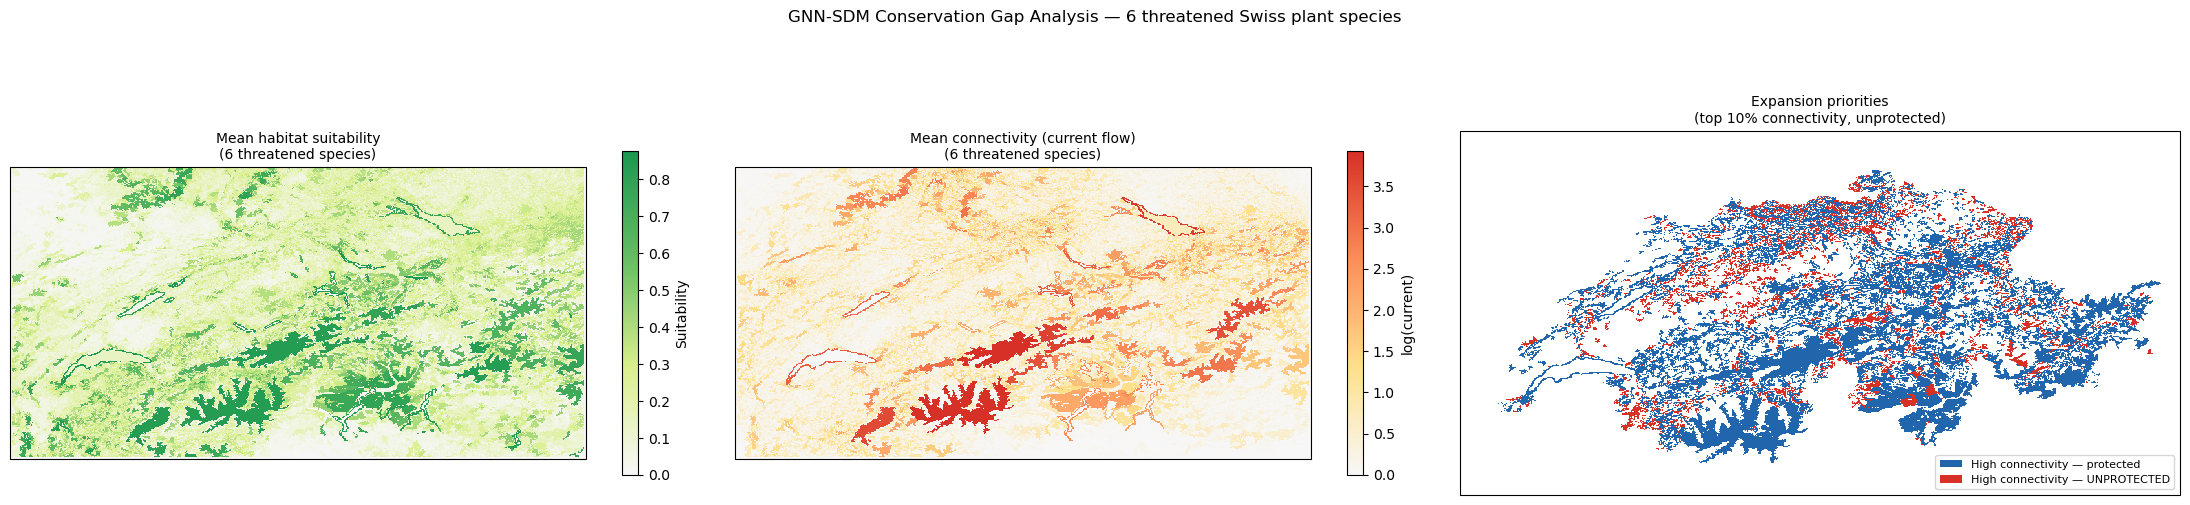

In [8]:
import cartopy.crs as ccrs
import numpy.ma as ma
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch
from geo_utils import BOUNDS

step = 20
extent = [BOUNDS['lon_min'], BOUNDS['lon_max'], BOUNDS['lat_min'], BOUNDS['lat_max']]

# Map suitability and connectivity to rasters (vectorised)
suit_raster = np.zeros_like(patch_labels, dtype=np.float32)
conn_raster = np.zeros_like(patch_labels, dtype=np.float32)
valid = patch_labels >= 0
suit_raster[valid] = mean_suitability[patch_labels[valid]]
conn_raster[valid] = mean_current[patch_labels[valid]]

# Expansion candidates raster
expansion_status = np.zeros(n_patches, dtype=np.float32)
for p in hc_protected:
    expansion_status[p] = 1  # already protected
for p in hc_unprotected:
    expansion_status[p] = 2  # expansion candidate
expansion_raster = np.full_like(patch_labels, np.nan, dtype=np.float32)
expansion_raster[valid] = expansion_status[patch_labels[valid]]
expansion_masked = ma.masked_where(expansion_raster == 0, expansion_raster)

# Colormaps
suit_cmap = LinearSegmentedColormap.from_list('suit', ['#f7f7f7', '#d9ef8b', '#66bd63', '#1a9850'])
conn_cmap = LinearSegmentedColormap.from_list('conn', ['#f7f7f7', '#fee08b', '#fc8d59', '#d73027'])
exp_cmap = ListedColormap(['#2166ac', '#d73027'])

fig, axes = plt.subplots(1, 3, figsize=(22, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Panel 1: Suitability (are we protecting the right places?)
ax = axes[0]
im = ax.imshow(suit_raster[::step, ::step], cmap=suit_cmap,
               vmin=0, vmax=mean_suitability.max(),
               extent=extent, origin='upper', interpolation='nearest',
               transform=ccrs.PlateCarree())
ax.set_title('Mean habitat suitability\n(6 threatened species)', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.6, label='Suitability')

# Panel 2: Connectivity (where are the corridors?)
ax = axes[1]
# Log-scale for visibility
conn_log = np.log1p(conn_raster * 100)
im = ax.imshow(conn_log[::step, ::step], cmap=conn_cmap,
               vmin=0, vmax=np.percentile(conn_log[valid], 99),
               extent=extent, origin='upper', interpolation='nearest',
               transform=ccrs.PlateCarree())
ax.set_title('Mean connectivity (current flow)\n(6 threatened species)', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.6, label='log(current)')

# Panel 3: Expansion candidates
ax = axes[2]
ax.imshow(expansion_masked[::step, ::step], cmap=exp_cmap, vmin=1, vmax=2,
          extent=extent, origin='upper', interpolation='nearest',
          transform=ccrs.PlateCarree())
legend_elements = [
    Patch(facecolor='#2166ac', label='High connectivity \u2014 protected'),
    Patch(facecolor='#d73027', label='High connectivity \u2014 UNPROTECTED'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
ax.set_title('Expansion priorities\n(top 10% connectivity, unprotected)', fontsize=10)

for ax in axes:
    ax.coastlines(linewidth=0.5)

plt.suptitle('GNN-SDM Conservation Gap Analysis \u2014 6 threatened Swiss plant species', fontsize=12)
plt.tight_layout()
plt.show()